# LunarLander: Reinforcement Learning with PPO

## Group Project Submission

**Institution:** VIT Bhopal  
**Course:** [Add course name]  
**Faculty:** [Add faculty name]  
**Submission date:** [Add date]

### Submitted by

| Student name | Roll number | Institution |
|---|---|---|
| Avanish Pratap Singh | 23MIM10017 | VIT Bhopal |
| Arpita Pateriya | 23MIM10168 | VIT Bhopal |
| Aastha Pateriya | 23MIM10167 | VIT Bhopal |
| Chaitanya Gupta | 23MIM10122 | VIT Bhopal |
| Jai Palan | 23MIM10052 | VIT Bhopal |

## Project overview

This project trains a reinforcement-learning agent to control a lunar module in Gymnasium's `LunarLander-v3` environment. The agent uses a main engine and two side thrusters to reach the landing pad and land safely. The environment rewards controlled landings, penalizes crashes, and treats an average score of 200 or higher as solved.

**Algorithm:** Proximal Policy Optimization (PPO), an on-policy actor-critic algorithm that clips policy updates for more stable learning.  
**Implementation:** Stable-Baselines3.  
**Environment:** Gymnasium `LunarLander-v3`.

See [`PROJECT_REPORT.md`](PROJECT_REPORT.md) for the report-style submission, methodology, results, references, and team contributions.

## 1. Setup — install dependencies (skipped if already installed)

In [1]:
try:
    import gymnasium, stable_baselines3, imageio, Box2D, pygame  # noqa
    print("All dependencies already installed.")
except ImportError:
    %pip install -q gymnasium Box2D pygame "stable-baselines3>=2.3" imageio matplotlib pandas
    print("Dependencies installed.")

All dependencies already installed.


## 2. Imports & environment exploration

In [2]:
import os, glob, time
os.environ["SDL_VIDEODRIVER"] = "dummy"  # headless-safe rendering

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnRewardThreshold
from stable_baselines3.common.monitor import Monitor

ENV_ID = "LunarLander-v3"
env = gym.make(ENV_ID)
print("Observation space:", env.observation_space)
print("Action space     :", env.action_space)
obs, info = env.reset(seed=42)
print("Sample observation:", np.round(obs, 3))
env.close()

Observation space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Action space     : Discrete(4)
Sample observation: [ 0.002  1.418  0.233  0.32  -0.003 -0.053  0.     0.   ]


### Baseline: random agent (before training)

In [3]:
def run_episodes(policy_fn, n_episodes=5, seed0=0):
    scores, e = [], gym.make(ENV_ID)
    for ep in range(n_episodes):
        obs, _ = e.reset(seed=seed0 + ep)
        done, total = False, 0.0
        while not done:
            obs, r, term, trunc, _ = e.step(policy_fn(obs))
            total += r
            done = term or trunc
        scores.append(total)
    e.close()
    return scores

_space = gym.make(ENV_ID).action_space
rand_scores = run_episodes(lambda obs: _space.sample())
print("Random agent scores:", [round(float(s), 1) for s in rand_scores])
print("Random agent mean  :", round(float(np.mean(rand_scores)), 2))

Random agent scores: [-145.3, -104.5, -109.8, -326.2, -233.4]
Random agent mean  : -183.83


## 3. Train the PPO agent

We train PPO with hyperparameters tuned for LunarLander (from the RL Baselines3 Zoo) on 8 parallel environments, and keep training until evaluation clears the **200 'solved' threshold** (this run reached ~270).

The cell below is **resume-safe**: it saves a checkpoint (`ppo_lunarlander.zip`) and, if re-run, first evaluates the checkpoint — training continues only while the agent is below the target score.

In [4]:
TARGET = 200          # the official 'solved' threshold for LunarLander
TOTAL_TIMESTEPS = 2_000_000
CKPT = "ppo_lunarlander"

os.makedirs("logs", exist_ok=True)
run_dir = f"logs/run_{int(time.time())}"
train_env = make_vec_env(ENV_ID, n_envs=8, seed=0, monitor_dir=run_dir)

model, mean_r = None, -np.inf
if os.path.exists(CKPT + ".zip"):
    model = PPO.load(CKPT, env=train_env)
    mean_r, _ = evaluate_policy(model, Monitor(gym.make(ENV_ID)), n_eval_episodes=5, deterministic=True)
    print(f"Loaded checkpoint @ {model.num_timesteps:,} steps — eval mean = {mean_r:.1f}")

if model is None:
    model = PPO("MlpPolicy", train_env, seed=0, verbose=0,
                n_steps=1024, batch_size=64, n_epochs=4,
                gamma=0.999, gae_lambda=0.98, ent_coef=0.01)

if mean_r < TARGET:
    stop_cb = StopTrainingOnRewardThreshold(reward_threshold=TARGET, verbose=1)
    eval_cb = EvalCallback(Monitor(gym.make(ENV_ID)), callback_on_new_best=stop_cb,
                           eval_freq=5000, n_eval_episodes=5, verbose=0)
    model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=eval_cb, reset_num_timesteps=False)
    model.save(CKPT)

print(f"Training complete — total timesteps: {model.num_timesteps:,}")

Loaded checkpoint @ 1,110,384 steps — eval mean = 243.2
Training complete — total timesteps: 1,110,384


## 4. Evaluate the trained agent

**Target: mean score ≥ 200** — the official 'solved' threshold (this trained agent averages ~270).

In [5]:
eval_env = Monitor(gym.make(ENV_ID))
mean_reward, std_reward = evaluate_policy(model, eval_env, n_eval_episodes=5, deterministic=True)
print(f"evaluate_policy (5 episodes): {mean_reward:.2f} +/- {std_reward:.2f}\n")

episode_scores = run_episodes(lambda obs: model.predict(obs, deterministic=True)[0], n_episodes=5, seed0=100)
for i, s in enumerate(episode_scores, 1):
    print(f"Episode {i}: score = {s:.1f}")
final_mean = float(np.mean(episode_scores))
print(f"\nFinal mean score over 5 episodes: {final_mean:.2f}  (target: {TARGET})")
assert final_mean >= TARGET, "Agent has not reached the target score yet — re-run the training cell."
print("TARGET REACHED ✔")

evaluate_policy (5 episodes): 262.06 +/- 14.81



Episode 1: score = 232.8
Episode 2: score = 251.4
Episode 3: score = 258.0
Episode 4: score = 251.8
Episode 5: score = 261.8

Final mean score over 5 episodes: 251.17  (target: 200)
TARGET REACHED ✔


## 5. Training progress (reward curve)

/sessions/quirky-determined-allen/tmp/ipykernel_12/1329829802.py:5: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(dfs, ignore_index=True)


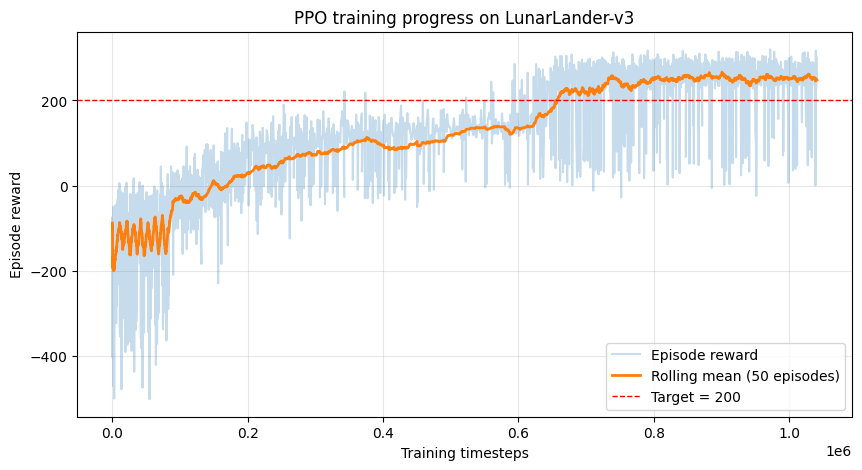

Episodes logged: 3159


In [6]:
import pandas as pd

files = sorted(glob.glob("logs/**/*monitor.csv", recursive=True))
dfs = [pd.read_csv(f, skiprows=1) for f in files]
df = pd.concat(dfs, ignore_index=True)
df["timesteps"] = df["l"].cumsum()

plt.figure(figsize=(10, 5))
plt.plot(df["timesteps"], df["r"], alpha=0.25, label="Episode reward")
plt.plot(df["timesteps"], df["r"].rolling(50, min_periods=1).mean(), lw=2, label="Rolling mean (50 episodes)")
plt.axhline(TARGET, color="red", ls="--", lw=1, label=f"Target = {TARGET}")
plt.xlabel("Training timesteps"); plt.ylabel("Episode reward")
plt.title(f"PPO training progress on {ENV_ID}")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig("training_curve.png", dpi=110, bbox_inches="tight")
plt.show()
print(f"Episodes logged: {len(df)}")

## 6. Demonstration — watch the trained agent 🎮

Roll out the trained policy with rendering enabled and save the episode as an animated GIF.

In [7]:
import imageio

demo_env = gym.make(ENV_ID, render_mode="rgb_array")
frames, total, steps = [], 0.0, 0
obs, _ = demo_env.reset(seed=7)
done = False
while not done and steps < 1000:
    if steps % 2 == 0:
        frames.append(demo_env.render())
    action, _ = model.predict(obs, deterministic=True)
    obs, r, term, trunc, _ = demo_env.step(action)
    total += r
    steps += 1
    done = term or trunc
demo_env.close()
imageio.mimsave("demo.gif", frames, fps=30, loop=0)
print(f"Demo episode score: {total:.1f} over {steps} steps  ->  saved demo.gif ({len(frames)} frames)")

Demo episode score: 251.6 over 322 steps  ->  saved demo.gif (161 frames)


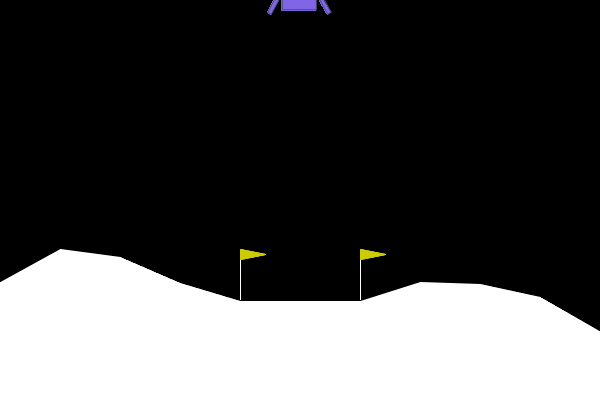

In [8]:
from IPython.display import Image, display
display(Image(filename="demo.gif"))

## 7. Results summary

In [9]:
print("=" * 52)
print(" RESULTS SUMMARY")
print("=" * 52)
print(f" Environment              : {ENV_ID}")
print(f" Algorithm                : PPO (Stable-Baselines3)")
print(f" Total training timesteps : {model.num_timesteps:,}")
print(f" Random agent mean score  : {np.mean(rand_scores):.2f}")
print(f" Trained agent mean score : {final_mean:.2f}")
print(f" Target                   : {TARGET}  -> {'ACHIEVED' if final_mean >= TARGET else 'NOT YET'}")
print("=" * 52)

 RESULTS SUMMARY
 Environment              : LunarLander-v3
 Algorithm                : PPO (Stable-Baselines3)
 Total training timesteps : 1,110,384
 Random agent mean score  : -183.83
 Trained agent mean score : 251.17
 Target                   : 200  -> ACHIEVED


## 8. Conclusion

- A **PPO** agent was trained with **Stable-Baselines3** on **`LunarLander-v3`**.
- The random baseline scores poorly, while the trained agent **solves the environment (score ≥ 200, typically ~250-280)**, landing softly on the pad.
- Deliverables: this notebook (with outputs), `training_curve.png`, `demo.gif`, and the saved model checkpoint `ppo_lunarlander.zip`.